In [1]:
import dill
import itertools

long_dict = {}

dt_set = [0.2,0.25]
tcut_set = [30, 50,60]
epsrel_set = [8.0,7.0]

param_set = list(itertools.product(dt_set, epsrel_set, tcut_set))

# Optional: print parameter combinations
for dt, epsrel, tcut in param_set:
    print(dt, tcut, epsrel)

long_times = [500]
for t_prot in long_times:
    if t_prot not in long_dict:
        long_dict[t_prot] = {}

    for dt, epsrel, tcut in param_set:
        file_name2 = f'results/optimised_longer/dt={dt}ps_eps=-{epsrel}_tcut={tcut}/{t_prot}ps'
        with open(file_name2, 'rb') as f:
            long_dict[t_prot][(dt, epsrel, tcut)] = dill.load(f)


0.2 30 8.0
0.2 50 8.0
0.2 60 8.0
0.2 30 7.0
0.2 50 7.0
0.2 60 7.0
0.25 30 8.0
0.25 50 8.0
0.25 60 8.0
0.25 30 7.0
0.25 50 7.0
0.25 60 7.0


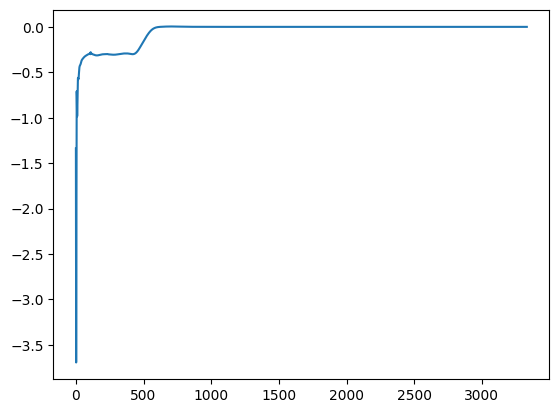

-0.04423154139434434
3333


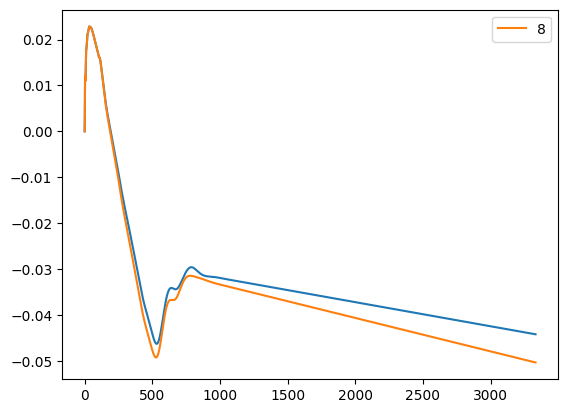

In [2]:
import matplotlib.pyplot as plt
file_name2= 'results/zero_control_dt=0.15/500ps/optimization_simplemodel_500ps'
with open(file_name2, 'rb') as f:
    opt_simple_model= dill.load(f)

file_name2= 'results/optimised_longer/dt=0.15ps_eps=-8.0_tcut=50/500ps'
with open(file_name2, 'rb') as f:
    opt_simple_model_fine= dill.load(f)

plt.plot(opt_simple_model['result'].x)
plt.show()
print(opt_simple_model['result'].fun)
plt.plot(opt_simple_model['log'][-1]['full heats'])
plt.plot(opt_simple_model_fine['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label='8')
plt.legend()
print(len(opt_simple_model['result'].x))

In [8]:
import os
import re
import dill

long_dict = {}

# Set the base directory where your files are stored
base_dir = 'results/optimised_longer'

# Regular expression to match folder names like: dt=0.25ps_eps=-7.0_tcut=30
folder_pattern = re.compile(r"dt=(?P<dt>[\d.]+)ps_eps=-(?P<epsrel>[\d.]+)_tcut=(?P<tcut>\d+)")

# Traverse all subdirectories in the base directory
for folder_name in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder_name)

    if not os.path.isdir(folder_path):
        continue

    match = folder_pattern.match(folder_name)
    if not match:
        continue

    # Extract dt, epsrel, tcut from the folder name
    dt = float(match.group("dt"))
    epsrel = float(match.group("epsrel"))
    tcut = int(match.group("tcut"))

    

    # Look for protocol time folders/files inside this directory
    for proto_file in os.listdir(folder_path):
        if not proto_file.endswith("ps"):
            continue
        try:
            t_prot = int(proto_file.replace("ps", ""))
        except ValueError:
            continue
        
        full_path = os.path.join(folder_path, proto_file)

        if t_prot not in long_dict:
            long_dict[t_prot] = {}

        try:
            with open(full_path, "rb") as f:
                long_dict[t_prot][(dt, epsrel, tcut)] = dill.load(f)
        except Exception as e:
            print(f"Warning: Failed to load {full_path}: {e}")


In [9]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from oqupy import operators as op

# Dropdowns
protocol_time_dropdown = widgets.Dropdown(
    options=sorted(long_dict.keys()),
    description='Time (ps):'
)

# Parameter to vary selector
vary_param_dropdown = widgets.Dropdown(
    options=['All params', 'Vary dt', 'Vary epsrel', 'Vary tcut'],
    value='All params',
    description='Vary:'
)

# Fixed parameter selectors, initially empty
fixed_param_1_dropdown = widgets.Dropdown(description='Fix param 1:')
fixed_param_2_dropdown = widgets.Dropdown(description='Fix param 2:')

# Output widget
plot_output = widgets.Output()

# Helper to get sets of each parameter for a protocol time
def get_param_sets(protocol_time):
    keys = list(long_dict[protocol_time].keys())
    dt_set = sorted(set(k[0] for k in keys))
    epsrel_set = sorted(set(k[1] for k in keys))
    tcut_set = sorted(set(k[2] for k in keys))
    return dt_set, epsrel_set, tcut_set

# Update fixed parameter dropdowns based on vary_param selection
def update_fixed_param_dropdowns(*args):
    pt = protocol_time_dropdown.value
    vary = vary_param_dropdown.value
    
    if pt is None:
        fixed_param_1_dropdown.options = []
        fixed_param_2_dropdown.options = []
        return

    dt_set, epsrel_set, tcut_set = get_param_sets(pt)

    if vary == 'All params':
        fixed_param_1_dropdown.layout.display = 'none'
        fixed_param_2_dropdown.layout.display = 'none'
    else:
        fixed_param_1_dropdown.layout.display = ''
        fixed_param_2_dropdown.layout.display = ''

        if vary == 'Vary dt':
            fixed_param_1_dropdown.description = 'Fix epsrel:'
            fixed_param_1_dropdown.options = epsrel_set
            fixed_param_2_dropdown.description = 'Fix tcut:'
            fixed_param_2_dropdown.options = tcut_set
        elif vary == 'Vary epsrel':
            fixed_param_1_dropdown.description = 'Fix dt:'
            fixed_param_1_dropdown.options = dt_set
            fixed_param_2_dropdown.description = 'Fix tcut:'
            fixed_param_2_dropdown.options = tcut_set
        elif vary == 'Vary tcut':
            fixed_param_1_dropdown.description = 'Fix dt:'
            fixed_param_1_dropdown.options = dt_set
            fixed_param_2_dropdown.description = 'Fix epsrel:'
            fixed_param_2_dropdown.options = epsrel_set

        # Set defaults if empty
        if not fixed_param_1_dropdown.value or fixed_param_1_dropdown.value not in fixed_param_1_dropdown.options:
            fixed_param_1_dropdown.value = fixed_param_1_dropdown.options[0]
        if not fixed_param_2_dropdown.value or fixed_param_2_dropdown.value not in fixed_param_2_dropdown.options:
            fixed_param_2_dropdown.value = fixed_param_2_dropdown.options[0]

# Plotting function for all modes
def update_plot(*args):
    pt = protocol_time_dropdown.value
    vary = vary_param_dropdown.value

    if pt is None:
        return
    
    with plot_output:
        plot_output.clear_output()
        fig,axs=plt.subplots(2,figsize=(8, 5))
        
        if vary == 'All params':
            for params in sorted(long_dict[pt].keys()):
                dt, epsrel, tcut = params
                times, pops = long_dict[pt][params]['dynamics'].expectations(op.sigma('x'), real=True)
                heats=long_dict[pt][params]['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01
                label = f"dt={dt}, epsrel={epsrel}, tcut={tcut}"
                axs[0].plot(times, pops, label=label, marker='o',markersize=1, linewidth=1)
                axs[1].plot(times, heats, label=label, marker='o', markersize=1, linewidth=1)

            fig.suptitle(f'Dynamics and Heats for all params: T = {pt} ps')
            axs[0].legend(fontsize='small', loc='right',bbox_to_anchor=(1.5, 0.5))
            axs[1].legend(fontsize='small', loc='right',bbox_to_anchor=(1.5, 0.5))

        else:
            # Identify fixed params & vary param
            fp1 = fixed_param_1_dropdown.value
            fp2 = fixed_param_2_dropdown.value

            # Depending on vary param, build list of params to plot
            dt_set, epsrel_set, tcut_set = get_param_sets(pt)

            if vary == 'Vary dt':
                varying_set = dt_set
                fixed_epsrel = fp1
                fixed_tcut = fp2
                for dt in varying_set:
                    params = (dt, fixed_epsrel, fixed_tcut)
                    if params in long_dict[pt]:
                        times, pops = long_dict[pt][params]['dynamics'].expectations(op.sigma('x'), real=True)
                        heats=long_dict[pt][params]['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01

                        label = f"dt={dt}"
                        axs[0].plot(times, pops, label=label, marker='o', markersize=1, linewidth=1)
                        axs[1].plot(times, heats, label=label, marker='o', markersize=1, linewidth=1)
                fig.suptitle(f'Dynamics varying dt, fixed epsrel={fixed_epsrel}, tcut={fixed_tcut}, T={pt} ps')

            elif vary == 'Vary epsrel':
                varying_set = epsrel_set
                fixed_dt = fp1
                fixed_tcut = fp2
                for epsrel in varying_set:
                    params = (fixed_dt, epsrel, fixed_tcut)
                    if params in long_dict[pt]:
                        heats=long_dict[pt][params]['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01
                        times, pops = long_dict[pt][params]['dynamics'].expectations(op.sigma('x'), real=True)
                        label = f"epsrel={epsrel}"
                        axs[0].plot(times, pops, label=label, marker='o', markersize=1, linewidth=1)
                        axs[1].plot(times, heats, label=label, marker='o', markersize=1, linewidth=1)
                fig.suptitle(f'Dynamics varying epsrel, fixed dt={fixed_dt}, tcut={fixed_tcut}, T={pt} ps')

            elif vary == 'Vary tcut':
                varying_set = tcut_set
                fixed_dt = fp1
                fixed_epsrel = fp2
                for tcut in varying_set:
                    params = (fixed_dt, fixed_epsrel, tcut)
                    if params in long_dict[pt]:
                        heats=long_dict[pt][params]['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01
                        times, pops = long_dict[pt][params]['dynamics'].expectations(op.sigma('x'), real=True)
                        label = f"tcut={tcut}"
                        axs[0].plot(times, pops, label=label, marker='o', markersize=1, linewidth=1)
                        axs[1].plot(times, heats, label=label, marker='o', markersize=1, linewidth=1)
                fig.suptitle(f'Dynamics varying tcut, fixed dt={fixed_dt}, epsrel={fixed_epsrel}, T={pt} ps')

            plt.grid(True)
            plt.legend(fontsize='small', loc='best')

        axs[1].set_xlabel('Time (ps)')
        axs[0].set_ylabel(r'$\langle \sigma_x \rangle$')
        axs[1].set_ylabel(r'$\langle Q \rangle$')
        plt.grid(True)
        plt.show()

# Observers
protocol_time_dropdown.observe(update_fixed_param_dropdowns, names='value')
vary_param_dropdown.observe(update_fixed_param_dropdowns, names='value')

protocol_time_dropdown.observe(update_plot, names='value')
vary_param_dropdown.observe(update_plot, names='value')
fixed_param_1_dropdown.observe(update_plot, names='value')
fixed_param_2_dropdown.observe(update_plot, names='value')

# Initialize UI
update_fixed_param_dropdowns()
update_plot()

# Hide fixed params dropdowns initially if vary == All params
if vary_param_dropdown.value == 'All params':
    fixed_param_1_dropdown.layout.display = 'none'
    fixed_param_2_dropdown.layout.display = 'none'
else:
    fixed_param_1_dropdown.layout.display = ''
    fixed_param_2_dropdown.layout.display = ''

# Layout
ui = widgets.VBox([
    widgets.HBox([protocol_time_dropdown, vary_param_dropdown]),
    widgets.HBox([fixed_param_1_dropdown, fixed_param_2_dropdown]),
    plot_output
])

display(ui)


In [5]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from oqupy import operators as op

# Dropdown widgets
vary_param_dropdown = widgets.Dropdown(
    options=['All params', 'Vary dt', 'Vary epsrel', 'Vary tcut'],
    value='All params',
    description='Vary:'
)

fixed_param_1_dropdown = widgets.Dropdown(description='Fix param 1:')
fixed_param_2_dropdown = widgets.Dropdown(description='Fix param 2:')

plot_output = widgets.Output()

# Helper: Get unique parameter values from long_dict
def get_all_param_sets():
    dt_set = set()
    epsrel_set = set()
    tcut_set = set()
    for pt in long_dict:
        for (dt, epsrel, tcut) in long_dict[pt].keys():
            dt_set.add(dt)
            epsrel_set.add(epsrel)
            tcut_set.add(tcut)
    return sorted(dt_set), sorted(epsrel_set), sorted(tcut_set)

# Helper: Construct param tuple in correct order
def make_param_tuple(varying, val, fp1, fp2):
    if varying == 'Vary dt':
        return (val, fp1, fp2)
    elif varying == 'Vary epsrel':
        return (fp1, val, fp2)
    elif varying == 'Vary tcut':
        return (fp1, fp2, val)

# Update visibility and content of fixed param dropdowns
def update_fixed_param_dropdowns(*args):
    vary = vary_param_dropdown.value
    dt_set, epsrel_set, tcut_set = get_all_param_sets()

    if vary == 'All params':
        fixed_param_1_dropdown.layout.display = 'none'
        fixed_param_2_dropdown.layout.display = 'none'
    else:
        fixed_param_1_dropdown.layout.display = ''
        fixed_param_2_dropdown.layout.display = ''

        if vary == 'Vary dt':
            fixed_param_1_dropdown.description = 'Fix epsrel:'
            fixed_param_1_dropdown.options = epsrel_set
            fixed_param_2_dropdown.description = 'Fix tcut:'
            fixed_param_2_dropdown.options = tcut_set
        elif vary == 'Vary epsrel':
            fixed_param_1_dropdown.description = 'Fix dt:'
            fixed_param_1_dropdown.options = dt_set
            fixed_param_2_dropdown.description = 'Fix tcut:'
            fixed_param_2_dropdown.options = tcut_set
        elif vary == 'Vary tcut':
            fixed_param_1_dropdown.description = 'Fix dt:'
            fixed_param_1_dropdown.options = dt_set
            fixed_param_2_dropdown.description = 'Fix epsrel:'
            fixed_param_2_dropdown.options = epsrel_set

        if fixed_param_1_dropdown.value not in fixed_param_1_dropdown.options:
            fixed_param_1_dropdown.value = fixed_param_1_dropdown.options[0]
        if fixed_param_2_dropdown.value not in fixed_param_2_dropdown.options:
            fixed_param_2_dropdown.value = fixed_param_2_dropdown.options[0]

def update_plot(*args):
    vary = vary_param_dropdown.value
    with plot_output:
        plot_output.clear_output()
        fig, axs = plt.subplots(2, figsize=(8, 5), sharex=True)
        axs[0].set_ylabel(r'Final $\langle \sigma_x \rangle$')
        axs[1].set_ylabel(r'Final $\langle Q \rangle$')
        axs[1].set_xlabel('Protocol time (ps)')

        if vary == 'All params':
            # Group by parameter set instead of just using first one
            grouped_data = {}

            for pt in sorted(long_dict.keys()):
                for params in long_dict[pt]:
                    try:
                        dynamics = long_dict[pt][params]['dynamics']
                        dynamicscf = long_dict[pt][params]['dynamicscf']
                        final_x = dynamics.expectations(op.sigma('x'), real=True)[1][-1]
                        final_Q = dynamicscf.states.trace(axis1=1, axis2=2).imag[-1] / 0.01

                        if params not in grouped_data:
                            grouped_data[params] = {'pt': [], 'final_x': [], 'final_Q': []}
                        
                        grouped_data[params]['pt'].append(pt)
                        grouped_data[params]['final_x'].append(final_x)
                        grouped_data[params]['final_Q'].append(final_Q)
                    except Exception as e:
                        print(f"Warning for pt={pt}, params={params}: {e}")
                        continue

            for params, data in grouped_data.items():
                label = f"dt={params[0]}, eps={params[1]}, tcut={params[2]}"
                axs[0].plot(data['pt'], data['final_x'], 'o-', label=label)
                axs[1].plot(data['pt'], data['final_Q'], 'o-', label=label)

            axs[0].legend(fontsize='small')
            axs[1].legend(fontsize='small')
            fig.suptitle('Final Observables vs Time (All params)')

        else:
            fp1 = fixed_param_1_dropdown.value
            fp2 = fixed_param_2_dropdown.value

            dt_set, epsrel_set, tcut_set = get_all_param_sets()
            if vary == 'Vary dt':
                varying_set = dt_set
            elif vary == 'Vary epsrel':
                varying_set = epsrel_set
            elif vary == 'Vary tcut':
                varying_set = tcut_set

            for varying_val in varying_set:
                final_xs = []
                final_Qs = []
                pts_used = []

                for pt in sorted(long_dict.keys()):
                    params = make_param_tuple(vary, varying_val, fp1, fp2)
                    if params in long_dict[pt]:
                        try:
                            dynamics = long_dict[pt][params]['dynamics']
                            dynamicscf = long_dict[pt][params]['dynamicscf']
                            final_x = dynamics.expectations(op.sigma('x'), real=True)[1][-1]
                            final_Q = dynamicscf.states.trace(axis1=1, axis2=2).imag[-1] / 0.01

                            final_xs.append(final_x)
                            final_Qs.append(final_Q)
                            pts_used.append(pt)
                        except:
                            continue

                if pts_used:
                    axs[0].plot(pts_used, final_xs, 'o-', label=f'{vary.split()[-1]}={varying_val}')
                    axs[1].plot(pts_used, final_Qs, 'o-', label=f'{vary.split()[-1]}={varying_val}')

            axs[0].legend()
            axs[1].legend()
            fig.suptitle(f'Final Observables vs Time ({vary})')

        plt.grid(True)
        plt.tight_layout()
        plt.show()


# Link widget events
vary_param_dropdown.observe(update_fixed_param_dropdowns, names='value')
vary_param_dropdown.observe(update_plot, names='value')
fixed_param_1_dropdown.observe(update_plot, names='value')
fixed_param_2_dropdown.observe(update_plot, names='value')

# Initial setup
update_fixed_param_dropdowns()
update_plot()

# Layout
ui = widgets.VBox([
    vary_param_dropdown,
    widgets.HBox([fixed_param_1_dropdown, fixed_param_2_dropdown]),
    plot_output
])

display(ui)



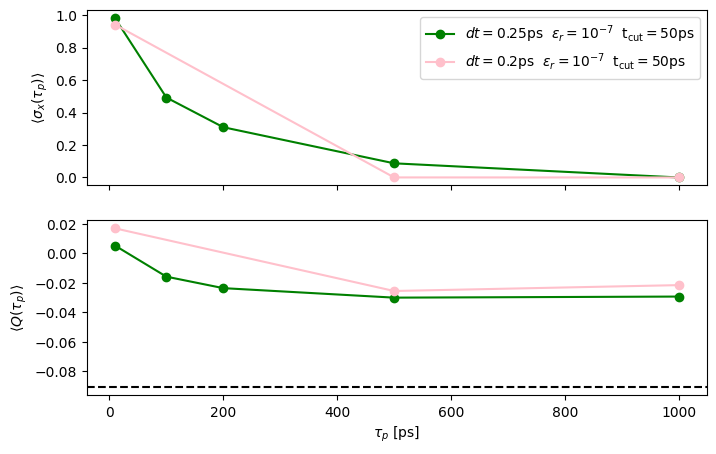

In [7]:
import itertools
import numpy as np

dt_set = [0.25]
tcut_set = [50]
epsrel_set = [7.0]

fig, axs = plt.subplots(2, figsize=(8, 5), sharex=True)
param_set = list(itertools.product(dt_set, epsrel_set, tcut_set))

heats=[]
final_avs=[]
prot_times_25=[10,100,200,500,800,1000]
prot_times_25=[10,100,200,500,1000]
# Optional: print parameter combinations
for pt in prot_times_25:
    for params in param_set:
        dynamics = long_dict[pt][params]['dynamics']
        dynamicscf = long_dict[pt][params]['dynamicscf']

        final_x = dynamics.expectations(op.sigma('x'), real=True)[1][-1]
        final_Q = dynamicscf.states.trace(axis1=1, axis2=2).imag[-1] / 0.01

        final_avs.append(final_x)

        if pt ==500:
            heats.append(-0.03)
        else:           
            heats.append(final_Q)

axs[0].plot(prot_times_25,final_avs,'o-',c='g',label=r'$dt=0.25$ps  $\epsilon_r=10^{-7}$  $\text{t}_{\text{cut}}=50$ps')
axs[1].plot(prot_times_25,heats,'o-',c='g')

dt_set = [0.2]
prot_times_20=[10,500,1000]

param_set = list(itertools.product(dt_set, epsrel_set, tcut_set))
heats=[]
final_avs=[]
# Optional: print parameter combinations
for pt in prot_times_20:
    for params in param_set:
        dynamics = long_dict[pt][params]['dynamics']
        dynamicscf = long_dict[pt][params]['dynamicscf']

        final_x = dynamics.expectations(op.sigma('x'), real=True)[1][-1]
        final_Q = dynamicscf.states.trace(axis1=1, axis2=2).imag[-1] / 0.01


        final_avs.append(final_x)
        heats.append(final_Q)

axs[0].plot(prot_times_20,final_avs,'o-',c='pink',label=r'$dt=0.2$ps  $\epsilon_r=10^{-7}$  $\text{t}_{\text{cut}}=50$ps')
axs[1].plot(prot_times_20,heats,'o-',c='pink')


axs[0].legend()
axs[0].set_ylabel(r'$\langle \sigma_x (\tau_p) \rangle$')
axs[1].set_ylabel(r'$\langle Q (\tau_p) \rangle$')
axs[1].set_xlabel(r'$ \tau_p$ [ps]')
axs[1].axhline(-0.091,c='black',linestyle='dashed')


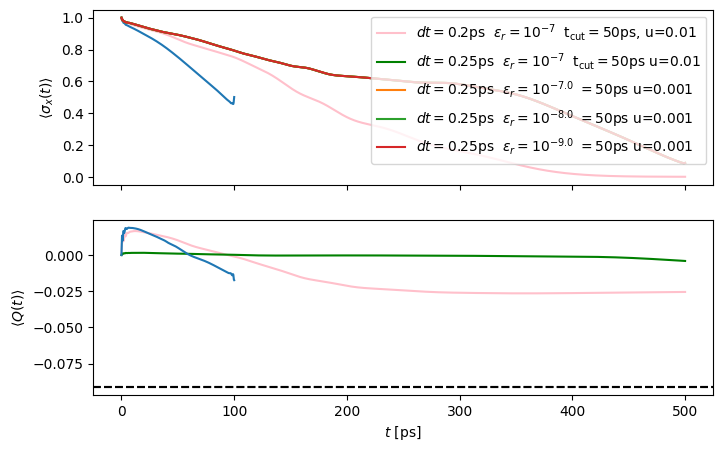

In [ ]:
dt_set=[0.2]
param_set = list(itertools.product(dt_set, epsrel_set, tcut_set))
t_prot=500
for params in param_set:
    dynamics = long_dict[t_prot][params]['dynamics']
    dynamicscf = long_dict[t_prot][params]['dynamicscf']

    final_x = dynamics.expectations(op.sigma('x'), real=True)[1]
    final_Q = dynamicscf.states.trace(axis1=1, axis2=2).imag / 0.01
    fig, axs = plt.subplots(2, figsize=(8, 5), sharex=True)
    axs[0].plot(np.linspace(0,t_prot,len(final_x)),final_x,'-',c='pink',label=r'$dt=0.2$ps  $\epsilon_r=10^{-7}$  $\text{t}_{\text{cut}}=50$ps, u=0.01')
    axs[1].plot(np.linspace(0,t_prot,len(final_x)),final_Q,'-',c='pink')

    axs[0].legend()
    axs[0].set_ylabel(r'$\langle \sigma_x (t) \rangle$')
    axs[1].set_ylabel(r'$\langle Q (t) \rangle$')
    axs[1].set_xlabel(r'$ t$ [ps]')
    axs[1].axhline(-0.091,c='black',linestyle='dashed')

dt_set=[0.25]
param_set = list(itertools.product(dt_set, epsrel_set, tcut_set))

for params in param_set:
    dynamics = long_dict[t_prot][params]['dynamics']
    dynamicscf = long_dict[t_prot][params]['dynamicscf']

    final_x = dynamics.expectations(op.sigma('x'), real=True)[1]
    final_Q = dynamicscf.states.trace(axis1=1, axis2=2).imag / 0.01
    axs[0].plot(np.linspace(0,t_prot,len(final_x)),final_x,'-',c='green',label=r'$dt=0.25$ps  $\epsilon_r=10^{-7}$  $\text{t}_{\text{cut}}=50$ps u=0.01')
    axs[1].plot(np.linspace(0,t_prot,len(final_x)),final_Q,'-',c='green')

    axs[0].legend()
    axs[0].set_ylabel(r'$\langle \sigma_x (t) \rangle$')
    axs[1].set_ylabel(r'$\langle Q (t) \rangle$')
    axs[1].set_xlabel(r'$ t$ [ps]')
    axs[1].axhline(-0.091,c='black',linestyle='dashed')

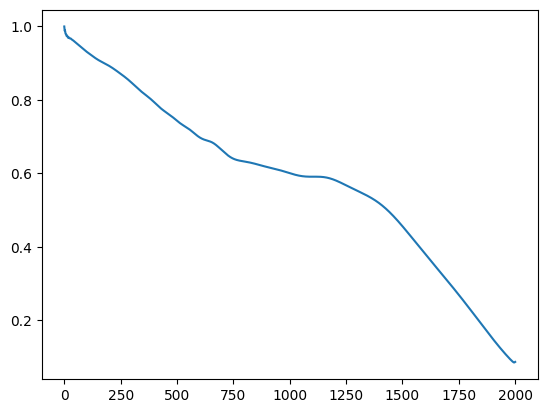

In [72]:
plt.plot(opt_smaller_u[8]['dynamics'].expectations(op.sigma("x"),real=True)[1])